In [ ]:
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv,noheader

import torch
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU name       : {torch.cuda.get_device_name(0)}")
print(f"VRAM total     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

NVIDIA A100-SXM4-40GB, 40960 MiB, 40442 MiB
CUDA available : True
GPU name       : NVIDIA A100-SXM4-40GB
VRAM total     : 42.4 GB


In [ ]:
%%capture
!pip install --upgrade --force-reinstall pyarrow
!pip install --upgrade --force-reinstall datasets
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install transformers trl peft accelerate bitsandbytes rouge-score
print("done")

In [ ]:
from google.colab import userdata

legalmod = userdata.get("legalmod")
assert legalmod and len(legalmod) > 10
print(f"✅ Token loaded: {legalmod[:8]}...")

from huggingface_hub import login
login(token=legalmod, add_to_git_credential=False)
print("✅ Logged in to HuggingFace")

✅ Token loaded: hf_QBllV...
✅ Logged in to HuggingFace


In [ ]:

from datasets import load_dataset

print("Loading SCOTUS Legal Reasoning dataset...")

raw = load_dataset("relai-ai/legal-scenarios-SCOTUS-2024-decisions", split="train", token=legalmod)

# 2. خلط البيانات واختيار حجم مناسب (بما أن حجمها الكلي صغير 208-321 صف، سنأخذها كاملة)
raw = raw.shuffle(seed=42)

print(f"Loaded         : {len(raw)} samples")
print(f"Columns        : {raw.column_names}")

# 3. عرض العينة بناءً على الأعمدة الفعلية (Question, Reasoning, Response)
print(f"\nSample Question  : {raw[0]['Question'][:150]}...")
print(f"Sample Reasoning : {raw[0]['Reasoning'][:200]}...")
print(f"Sample Response  : {raw[0]['Response'][:150]}...")

Loading SCOTUS Legal Reasoning dataset...


(…)0SCOTUS%202024%20Decisions%20Samples.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/208 [00:00<?, ? examples/s]

Loaded         : 208 samples
Columns        : ['Question', 'Response', 'Reasoning']

Sample Question  : In the state of Regalia, election officials disqualify a presidential candidate for insurrection under Section 3 of the Fourteenth Amendment. At the s...
Sample Reasoning : To resolve the conflict between state actions disqualifying a candidate and federal authority to remove such disqualification, we must consider federalism principles and relevant Supreme Court precede...
Sample Response  : The conflict is best resolved by Congress utilizing its power under Section 5 of the Fourteenth Amendment, as underscored by McCulloch v. Maryland and...


In [ ]:
import pandas as pd

df = pd.DataFrame(raw)
print("Raw columns:", list(df.columns))

# ── Step 1: keep only what we need ───────────────────────────────────────────
# الأعمدة الحقيقية في الداتا: Question, Reasoning, Response
df = df[["Question", "Reasoning", "Response"]].copy()

# ── Step 2: rename to match our pipeline ─────────────────────────────────────
# تم استبدال Reasoning بـ input بناءً على اتفاقنا
df = df.rename(columns={
    "Question": "instruction",
    "Reasoning": "input",
    "Response": "output"
})

# ── Step 3: force string type ─────────────────────────────────────────────────
df["instruction"] = df["instruction"].astype(str)
df["input"]       = df["input"].astype(str)
df["output"]      = df["output"].astype(str)

# ── Step 4: remove rows that became "nan" after casting ───────────────────────
df = df[df["instruction"] != "nan"]
df = df[df["input"] != "nan"]
df = df[df["output"] != "nan"]

original = len(df)
print(f"\nAfter nan removal : {original} rows")

print(f"\nOutput length stats:")
print(df["output"].str.len().describe().round(0))

# ── Step 5: filters tuned for legal dataset ───────────────────────────────────
df = df.drop_duplicates(subset=["instruction"])
df = df[df["instruction"].str.len() >= 15]
df = df[df["output"].str.len() >= 50]
df = df[df["output"].str.len() <= 3000]
df = df[~df["output"].str.startswith("I ")]

df = df.reset_index(drop=True)

# ── Final summary ─────────────────────────────────────────────────────────────
print(f"\nOriginal  : {original}")
print(f"Cleaned   : {len(df)}")
print(f"Removed   : {original - len(df)}")
print(f"\nFinal columns : {list(df.columns)}")

# ── Sample check ─────────────────────────────────────────────────────────────
print(f"\nSample Q : {df['instruction'].iloc[0]}")
print(f"Sample I : {df['input'].iloc[0][:200]}")
print(f"Sample A : {df['output'].iloc[0][:200]}")

Raw columns: ['Question', 'Response', 'Reasoning']

After nan removal : 208 rows

Output length stats:
count    208.0
mean     317.0
std       62.0
min      199.0
25%      275.0
50%      309.0
75%      342.0
max      648.0
Name: output, dtype: float64

Original  : 208
Cleaned   : 208
Removed   : 0

Final columns : ['instruction', 'input', 'output']

Sample Q : In the state of Regalia, election officials disqualify a presidential candidate for insurrection under Section 3 of the Fourteenth Amendment. At the same time, the Constitution allows Congress, by a two‑thirds vote, to remove such disqualification. Given the tension between state actions limiting candidate eligibility and federal authority to remedy these limits, what legal solution would best resolve this conflict?
Sample I : To resolve the conflict between state actions disqualifying a candidate and federal authority to remove such disqualification, we must consider federalism principles and relevant Supreme Court precede
Sampl

In [ ]:
import os
from unsloth import FastLanguageModel
import torch

# ── تفعيل ModelScope (اختياري) ─────────────────────────
os.environ["UNSLOTH_USE_MODELSCOPE"] = "1"

# ── اسم الموديل (خفيف ومستقر) ─────────────────────────
model_name = "unsloth/phi-4-bnb-4bit"

# ── تحميل الموديل بشكل آمن ─────────────────────────────
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name,
    max_seq_length = 2048,
    dtype          = None,
    load_in_4bit   = True,
)

print("✅ Model loaded successfully")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/170 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Model loaded successfully


In [ ]:
from datasets import Dataset

# تم تعديل القالب ليستخدم كلمة Input بدلاً من Context ليتطابق مع بياناتك
ALPACA_TEMPLATE = """Below is a legal question based on a SCOTUS case.
Write a clear legal reasoning analysis followed by the final court decision.

### Question:
{instruction}

### Input:
{input}

### Answer:
{output}"""

EOS = tokenizer.eos_token # علامة نهاية النص لإيقاف النموذج عن الهذيان

# 7. دالة التنسيق النهائية (تصحيح الخطأ KeyError)
# الوظيفة: دمج الأعمدة الثلاثة في نص واحد طويل للتدريب
def format_row(row):
    return ALPACA_TEMPLATE.format(
        instruction = row["instruction"], # جلب السؤال من العمود الجديد
        input       = row["input"],       # جلب المنطق (Reasoning) من العمود الجديد
        output      = row["output"],      # جلب الإجابة من العمود الجديد
    ) + row["output"] + EOS


# ── Apply template ─────────────────────────────────────────────
df["text"] = df.apply(format_row, axis=1)

# ── Remove overly long samples ─────────────────────────────────
df = df[df["text"].str.len() <= 6000]
df = df.reset_index(drop=True)

print(f"Samples after length trim : {len(df)}")
print(f"Text length median         : {df['text'].str.len().median():.0f} chars")
print(f"Text length max            : {df['text'].str.len().max():.0f} chars")


# ── Convert to HuggingFace Dataset ─────────────────────────────
# تم تعديل اختيار الأعمدة هنا ليكون (instruction, input, output)
df_final = df[["instruction", "input", "output", "text"]].copy()
df_final = df_final.reset_index(drop=True)

hf_data = Dataset.from_pandas(df_final, preserve_index=False)

split = hf_data.train_test_split(test_size=0.1, seed=42)

train_dataset = split["train"]
test_dataset  = split["test"]


# ── Results ────────────────────────────────────────────────────
print(f"\n✅ Legal Dataset ready")
print(f"   Train : {len(train_dataset)} samples")
print(f"   Test  : {len(test_dataset)} samples")

print(f"\nFormatted example:")
print(df_final["text"].iloc[0][:500])
print("...")

Samples after length trim : 208
Text length median         : 2004 chars
Text length max            : 2831 chars

✅ Legal Dataset ready
   Train : 187 samples
   Test  : 21 samples

Formatted example:
Below is a legal question based on a SCOTUS case.
Write a clear legal reasoning analysis followed by the final court decision.

### Question:
In the state of Regalia, election officials disqualify a presidential candidate for insurrection under Section 3 of the Fourteenth Amendment. At the same time, the Constitution allows Congress, by a two‑thirds vote, to remove such disqualification. Given the tension between state actions limiting candidate eligibility and federal authority to remedy these 
...


In [ ]:
FastLanguageModel.for_inference(model)  #   للموديل قبل التدريب تفعيل وضع الاستنتاج

def generate_legal_response(mdl, question, max_tokens=250):
    # المستوى الأول: 4 مسافات تبدأ من هنا لكل ما هو داخل الدالة
    prompt = ALPACA_TEMPLATE.format(
        instruction = question,
        input       = "",
        output      = ""
    ).rstrip()

    # تأكدي أن هذا السطر يبدأ تماماً تحت حرف p في كلمة prompt
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    # تأكدي أن هذا السطر أيضاً محاذٍ عمودياً لما قبله
    with torch.no_grad():
        outputs = mdl.generate(
            **inputs,
            max_new_tokens     = max_tokens,
            temperature        = 0.4,
            do_sample          = True,
            top_p              = 0.9,
            repetition_penalty = 1.2,
            pad_token_id       = tokenizer.eos_token_id,
        )

    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


# ── أسئلة اختبار قانونية ─────────────────────────
TEST_QUESTIONS = [
    "What constitutional issues are raised when a state law bans the burning of the American flag?",
    "Does the Fourth Amendment protect a person from GPS tracking by the police without a warrant?",
    "Explain the legal reasoning behind the 'Separate but Equal' doctrine being overturned.",
    "Can a public school official search a student's belongings without a warrant?",
    "What is the capital of France?"
]

base_responses = {}

print("BASE MODEL RESPONSES — Testing Phi-4 before Legal Fine-tuning")
print("=" * 60)

for q in TEST_QUESTIONS:
    resp = generate_legal_response(model, q)
    base_responses[q] = resp

    print(f"\nQuestion: {q}")
    print(f"Model Output:\n{resp}")
    print("-" * 60)

print(f"\n✅ Saved {len(base_responses)} base responses for later comparison")

BASE MODEL RESPONSES — Testing Phi-4 before Legal Fine-tuning


Both `max_new_tokens` (=250) and `max_length`(=16384) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12


Question: What constitutional issues are raised when a state law bans the burning of the American flag?
Model Output:
The Supreme Court has addressed the issue of whether a state can ban the act of burning an American flag in Texas v. Johnson, 491 U.S. 397 (1989). In this landmark case, Gregory Lee Johnson burned an American flag outside of the convention center where the Republican National Convention was being held in Dallas, Texas.

The primary constitutional issue at stake here revolves around the First Amendment to the United States Constitution, which protects freedom of speech and expression from government interference. Specifically, the question before the Court was whether the State's interest in preserving the physical integrity of the national symbol—the flag—outweighs the individual's right to free expressive conduct under the First Amendment.

In its opinion, delivered by Justice Brennan, the Court applied strict scrutiny because it involved symbolic speech that did not 

Both `max_new_tokens` (=250) and `max_length`(=16384) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Question: Does the Fourth Amendment protect a person from GPS tracking by the police without a warrant?
Model Output:
The issue at hand concerns whether law enforcement's use of a Global Positioning System (GPS) device to monitor and track an individual’s movements constitutes a "search" under the Fourth Amendment, which protects against unreasonable searches and seizures.

In United States v. Jones, 565 U.S. 400 (2012), the Supreme Court addressed this very question. In that case, officers placed a GPS tracker on Antoine Jones' vehicle while it was parked in his private garage—without obtaining a valid search warrant—and monitored its location for twenty-eight days. This information led them to arrest Mr. Jones for drug trafficking charges after they observed patterns consistent with narcotics distribution.

The majority opinion, delivered by Justice Scalia, held that attaching the GPS device to the exterior of the Jeep constituted a physical intrusion into a constitutionally protect

Both `max_new_tokens` (=250) and `max_length`(=16384) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Question: Explain the legal reasoning behind the 'Separate but Equal' doctrine being overturned.
Model Output:
The "separate but equal" doctrine was established in 1896 with the U.S. Supreme Court's ruling in Plessy v. Ferguson, which upheld state racial segregation laws for public facilities under the doctrine of "separate but equal." This meant that as long as the separate facilities provided to each race were purportedly equal, their separation did not violate the Fourteenth Amendment.

However, this doctrine began to be challenged over time, culminating in its overturning through several key cases leading up to and including Brown v. Board of Education (1954). Here’s an outline of the legal reasoning that led to the dismantling of "separate but equal":

1. **Inherent Inequality**: Legal challenges argued that segregated schools are inherently unequal because they instill feelings of inferiority among African American children that can affect their hearts and minds in ways unlikely

Both `max_new_tokens` (=250) and `max_length`(=16384) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Question: Can a public school official search a student's belongings without a warrant?
Model Output:
To determine whether a public school official can search a student's belongings without a warrant, we must analyze relevant Supreme Court cases that address this issue.

The key precedent in this area is New Jersey v. T.L.O., 469 U.S. 325 (1985). In this case, the Supreme Court held that while students have Fourth Amendment rights against unreasonable searches and seizures, these rights are balanced differently within the context of public schools compared to other settings due to the unique environment and needs for maintaining order and discipline.

**Legal Reasoning Analysis:**

1. **Fourth Amendment Protections**: The Fourth Amendment protects individuals from unreasonable searches and seizures. However, its application varies depending on the setting and circumstances.
   
2. **School Environment Considerations**: Public schools operate under different standards than law enforcem

In [ ]:
import json

# حفظ الإجابات في ملف نصي بسيط
with open("base_model_results.json", "w") as f:
    json.dump(base_responses, f, indent=4)

print("✅ تم حفظ الإجابات في ملف base_model_results.json")

✅ تم حفظ الإجابات في ملف base_model_results.json


In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r                          = 4,      #صغرناها لانو الداتا صغيرة
    lora_alpha                 = 8,      #
    lora_dropout               = 0.05,       #حتى ما يحث اوفر فتنج
    bias                       = "none",
    target_modules             = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    use_gradient_checkpointing = "unsloth",
    random_state               = 42,
)

# حساب المعاملات القابلة للتدريب
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params     : {total:,}")
print(f"Trainable params : {trainable:,}")
print(f"Trainable %      : {trainable / total * 100:.3f}%")
print(f"VRAM used        : {torch.cuda.memory_allocated()/1e9:.2f} GB")

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 40 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


Total params     : 7,860,147,200
Trainable params : 16,384,000
Trainable %      : 0.208%
VRAM used        : 9.30 GB


In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
import time

total_steps = 62  #عدد مرات الاختبار

trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = train_dataset,
    dataset_text_field = "text",
    max_seq_length     = 2048,   # ✅ تم تقليله للاستقرار والسرعة

    args = TrainingArguments(
        output_dir                  = "/content/checkpoints",
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,

        warmup_steps                = 5,      # ✅ بدل warmup_ratio (أكثر استقرارًا)
        num_train_epochs            = 3,

        learning_rate               = 3e-5,   # ✅ أفضل من 2e-5 و 2e-4 لموازنة التعلم

        fp16                        = not torch.cuda.is_bf16_supported(),
        bf16                        = torch.cuda.is_bf16_supported(),

        logging_steps               = 10,
        save_strategy               = "epoch",

        optim                       = "adamw_8bit",
        weight_decay                = 0.01,
        lr_scheduler_type           = "cosine",

        seed                        = 42,
        report_to                   = "none",
    ),
)

print("Training started — optimized version 🚀")
print("=" * 60)

t0 = time.time()
trainer_stats = trainer.train()
elapsed = time.time() - t0

print(f"\n✅ Training complete")
print(f"Time       : {elapsed/60:.1f} minutes")
print(f"Final loss : {trainer_stats.training_loss:.4f}")
print(f"Peak VRAM  : {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/187 [00:00<?, ? examples/s]

Training started — optimized version 🚀


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 187 | Num Epochs = 3 | Total steps = 72
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 16,384,000 of 14,675,891,200 (0.11% trained)


Step,Training Loss
10,1.559043
20,1.407067
30,1.328216
40,1.268406
50,1.249505
60,1.228326
70,1.202923



✅ Training complete
Time       : 2.4 minutes
Final loss : 1.3180
Peak VRAM  : 21.82 GB


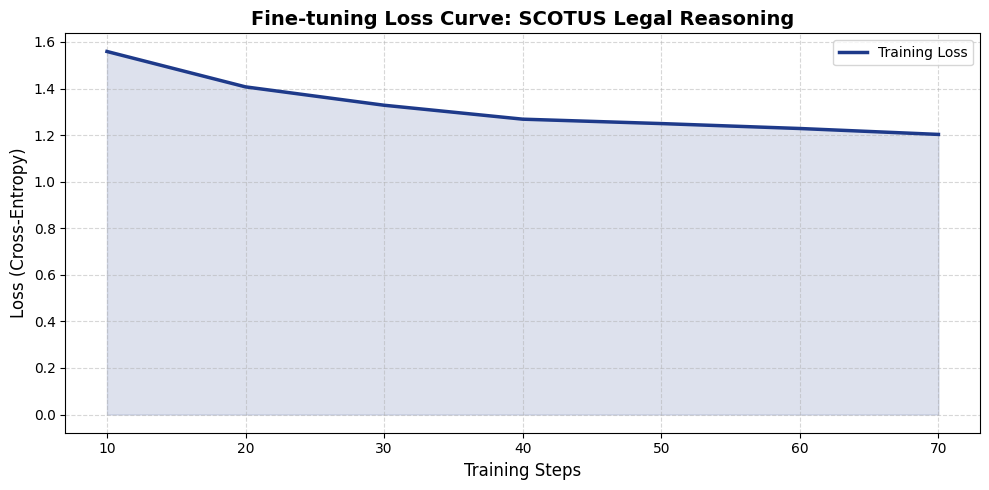


📊 TRAINING SUMMARY
Initial Loss : 1.5590
Final Loss   : 1.2029
Reduction    : 22.8%


In [ ]:
import matplotlib.pyplot as plt

# 1. استخراج سجلات التدريب من الـ trainer
logs   = trainer.state.log_history
steps  = [x["step"] for x in logs if "loss" in x]
losses = [x["loss"]  for x in logs if "loss" in x]

# 2. إعداد الرسم البياني
plt.figure(figsize=(10, 5))
# استخدمنا اللون الأزرق الداكن (Midnight Blue) ليتناسب مع الطابع القانوني
plt.plot(steps, losses, color="#1e3a8a", linewidth=2.5, label="Training Loss")
plt.fill_between(steps, losses, alpha=0.15, color="#1e3a8a")

# 3. المسميات قانونية)
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss (Cross-Entropy)", fontsize=12)
plt.title("Fine-tuning Loss Curve: SCOTUS Legal Reasoning", fontweight="bold", fontsize=14)

# 4. تحسين مظهر الشبكة
plt.grid(visible=True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# 5. طباعة ملخص النتائج الرقمية
if losses:
    start_loss = losses[0]
    end_loss = losses[-1]
    reduction = (start_loss - end_loss) / start_loss * 100

    print(f"\n" + "="*30)
    print(f"📊 TRAINING SUMMARY")
    print(f"="*30)
    print(f"Initial Loss : {start_loss:.4f}")
    print(f"Final Loss   : {end_loss:.4f}")
    print(f"Reduction    : {reduction:.1f}%")
    print(f"="*30)
else:
    print("❌ No training logs found. Ensure training has completed.")

In [ ]:
import sys

# التأكد من أن النموذج في وضع الاستدلال
FastLanguageModel.for_inference(model)

ft_responses = {}

print("SIDE-BY-SIDE: BASE vs FINE-TUNED")
print("=" * 70)

for q in TEST_QUESTIONS:
    ft_resp  = generate_legal_response(model, q)
    ft_responses[q] = ft_resp

    print(f"\n{'━'*70}")
    print(f"Q: {q}")
    print(f"\n🔵 BASE:\n{base_responses[q]}")
    print(f"\n🟢 FINE-TUNED:\n{ft_resp}")

print(f"\n{'━'*70}")
print("Last question = catastrophic forgetting test")
print("Did fine-tuned model still answer correctly?")


Both `max_new_tokens` (=250) and `max_length`(=16384) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


SIDE-BY-SIDE: BASE vs FINE-TUNED


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=250) and `max_length`(=16384) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Q: What constitutional issues are raised when a state law bans the burning of the American flag?

🔵 BASE:
The Supreme Court has addressed the issue of whether a state can ban the act of burning an American flag in Texas v. Johnson, 491 U.S. 397 (1989). In this landmark case, Gregory Lee Johnson burned an American flag outside of the convention center where the Republican National Convention was being held in Dallas, Texas.

The primary constitutional issue at stake here revolves around the First Amendment to the United States Constitution, which protects freedom of speech and expression from government interference. Specifically, the question before the Court was whether the State's interest in preserving the physical integrity of the national symbol—the flag—outweighs the individual's right to free expressive conduct under the First Amendment.

In its opinion, delivered by Justice Brennan, the Court applied strict

Both `max_new_tokens` (=250) and `max_length`(=16384) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Q: Does the Fourth Amendment protect a person from GPS tracking by the police without a warrant?

🔵 BASE:
The issue at hand concerns whether law enforcement's use of a Global Positioning System (GPS) device to monitor and track an individual’s movements constitutes a "search" under the Fourth Amendment, which protects against unreasonable searches and seizures.

In United States v. Jones, 565 U.S. 400 (2012), the Supreme Court addressed this very question. In that case, officers placed a GPS tracker on Antoine Jones' vehicle while it was parked in his private garage—without obtaining a valid search warrant—and monitored its location for twenty-eight days. This information led them to arrest Mr. Jones for drug trafficking charges after they observed patterns consistent with narcotics distribution.

The majority opinion, delivered by Justice Scalia, held that attaching the GPS device to the exterior of the Jeep const

Both `max_new_tokens` (=250) and `max_length`(=16384) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Q: Explain the legal reasoning behind the 'Separate but Equal' doctrine being overturned.

🔵 BASE:
The "separate but equal" doctrine was established in 1896 with the U.S. Supreme Court's ruling in Plessy v. Ferguson, which upheld state racial segregation laws for public facilities under the doctrine of "separate but equal." This meant that as long as the separate facilities provided to each race were purportedly equal, their separation did not violate the Fourteenth Amendment.

However, this doctrine began to be challenged over time, culminating in its overturning through several key cases leading up to and including Brown v. Board of Education (1954). Here’s an outline of the legal reasoning that led to the dismantling of "separate but equal":

1. **Inherent Inequality**: Legal challenges argued that segregated schools are inherently unequal because they instill feelings of inferiority among African American child

Both `max_new_tokens` (=250) and `max_length`(=16384) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Q: Can a public school official search a student's belongings without a warrant?

🔵 BASE:
To determine whether a public school official can search a student's belongings without a warrant, we must analyze relevant Supreme Court cases that address this issue.

The key precedent in this area is New Jersey v. T.L.O., 469 U.S. 325 (1985). In this case, the Supreme Court held that while students have Fourth Amendment rights against unreasonable searches and seizures, these rights are balanced differently within the context of public schools compared to other settings due to the unique environment and needs for maintaining order and discipline.

**Legal Reasoning Analysis:**

1. **Fourth Amendment Protections**: The Fourth Amendment protects individuals from unreasonable searches and seizures. However, its application varies depending on the setting and circumstances.
   
2. **School Environment Considerations**: Public 

In [ ]:
import json

# تجهيز البيانات للحفظ بشكل منظم
comparison_data = []
for q in TEST_QUESTIONS:
    comparison_data.append({
        "question": q,
        "base_model_response": base_responses.get(q, ""),
        "fine_tuned_model_response": ft_responses.get(q, "")
    })

# حفظ الملف في مسار العمل الحالي
file_path = "legal_model_comparison_results.json"
with open(file_path, "w", encoding="utf-8") as f:
    json.dump(comparison_data, f, ensure_ascii=False, indent=4)

print(f"✅ تم حفظ جميع الإجابات بنجاح في: {file_path}")

✅ تم حفظ جميع الإجابات بنجاح في: legal_model_comparison_results.json


In [ ]:
from torch.nn import CrossEntropyLoss
import torch

def compute_perplexity(mdl, texts, max_length=1024): # رفعنا الطول ليناسب التحليل القانوني
    mdl.eval()
    total_loss, total_tokens = 0.0, 0

    for text in texts:
        # التأكد من أن النص ليس فارغاً لتجنب أخطاء الحساب
        if not text or len(text.strip()) == 0:
            continue

        inputs = tokenizer(
            text,
            return_tensors  = "pt",
            truncation      = True,
            max_length      = max_length
        ).to("cuda")

        with torch.no_grad():
            out = mdl(**inputs, labels=inputs["input_ids"])

        # نضرب الخسارة في عدد التوكنز للحصول على المجموع التراكمي بدقة
        total_loss   += out.loss.item() * inputs["input_ids"].numel()
        total_tokens += inputs["input_ids"].numel()

    # الحساب النهائي للحيرة (Perplexity) باستخدام الدالة الأسية لمتوسط الخسارة
    if total_tokens == 0: return float('inf')
    return torch.exp(torch.tensor(total_loss / total_tokens)).item()

# اختيار عينات من مجموعة الاختبار (test_dataset) التي تم فصلها بنسبة 10% سابقاً
num_eval_samples = min(20, len(test_dataset))
eval_texts = test_dataset.select(range(num_eval_samples))["text"]

print(f"Computing perplexity on {num_eval_samples} legal test samples...")
ft_ppl = compute_perplexity(model, eval_texts)

print(f"\nFine-tuned Perplexity : {ft_ppl:.2f}")
print("--------------------------------------------------")
print("Lower = model fits SCOTUS legal reasoning better.")
print("Typical expert legal model range: 2.0 to 8.0")
print("--------------------------------------------------")

Computing perplexity on 20 legal test samples...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)



Fine-tuned Perplexity : 3.45
--------------------------------------------------
Lower = model fits SCOTUS legal reasoning better.
Typical expert legal model range: 2.0 to 8.0
--------------------------------------------------


In [ ]:

from google.colab import drive
drive.mount('/content/drive')
import os

model.save_pretrained("/content/legal_lorayes*")
tokenizer.save_pretrained("/content/legal_lorayes*")

size_mb = sum(
    os.path.getsize(f"/content/legal_lorayes*/{f}")
    for f in os.listdir("/content/legal_lorayes*")
) / 1e6

print(f"✅ Saved to /content/legal_lorayes*/")
print(f"   Size  : {size_mb:.1f} MB")
print(f"   Files : {os.listdir('/content/legal_lorayes*')}")

# Uncomment to save to Google Drive so it survives session end
# from google.colab import drive
# drive.mount("/content/drive")
# model.save_pretrained("/content/drive/My Drive/legal_lora")
# tokenizer.save_pretrained("/content/drive/My Drive/legal_lora")
# print("✅ Also saved to Google Drive")

MessageError: Error: credential propagation was unsuccessful

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.5 MB/s eta 0:00:00
Judging 1/4: What constitutional issues are raised when a state...
Judging 2/4: Does the Fourth Amendment protect a person from GP...
Judging 3/4: Explain the legal reasoning behind the 'Separate b...
Judging 4/4: Can a public school official search a student's be...

EVALUATION SCORECARD

Q: What constitutional issues are raised when a state law bans ...
  Base → Acc:5 Reason:5 Tone:5 Total:15/15
  FT   → Acc:4 Reason:4 Tone:4 Total:12/15
  🔵 BASE wins | Response A provides a more detailed and accurate explanation of the Texas v. Johnson case and its implications for First Amendment rights.

Q: Does the Fourth Amendment protect a person from GPS tracking...
  Base → Acc:5 Reason:5 Tone:5 Total:15/15
  FT   → Acc:4 Reason:4 Tone:4 Total:12/15
  🔵 BASE wins | Response A provides a more detailed and accurate analysis of the United States v. Jones case and its implications for Fourth Amendment protections.

Q:

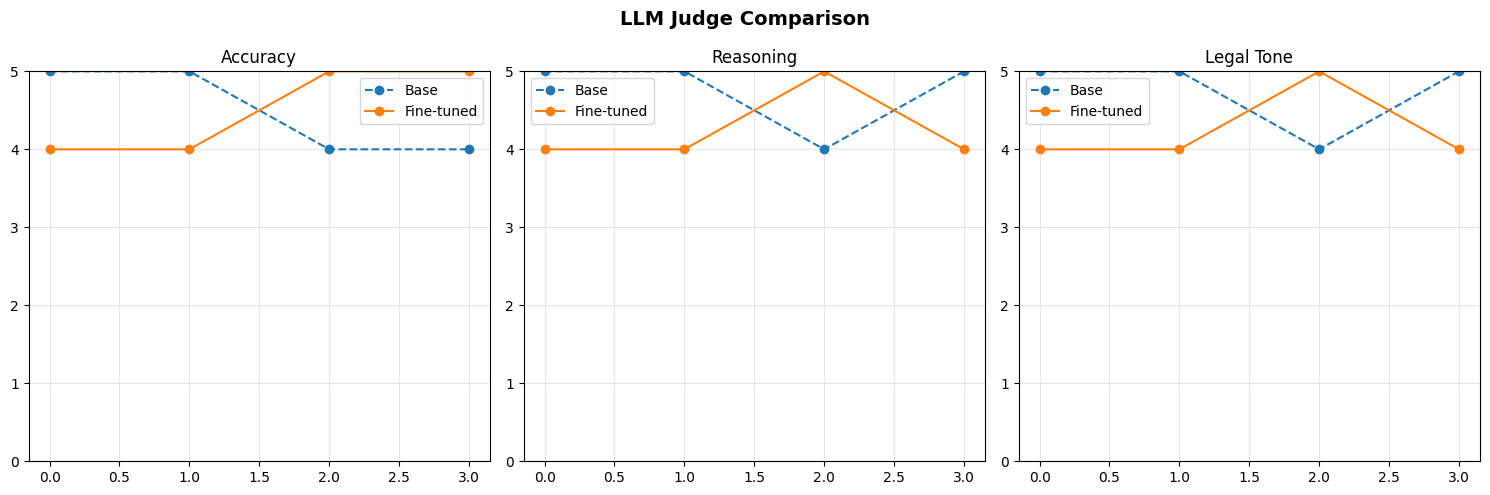

In [ ]:
!pip install groq

from groq import Groq
import json, re, time
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata

# ── API KEY ─────────────────────────────────────────────────────
GROK_API_KEY = userdata.get("GROK_API_KEY")
assert GROK_API_KEY and len(GROK_API_KEY) > 10, "GROQ_API_KEY missing from Colab Secrets"

client = Groq(api_key=GROK_API_KEY.strip())


# ── JUDGE PROMPT ────────────────────────────────────────────────
JUDGE_PROMPT = """You are an expert SCOTUS legal scholar.
Compare two AI responses to a complex legal or constitutional question.

QUESTION: {question}

RESPONSE A:
{response_a}

RESPONSE B:
{response_b}

Score each response from 1 to 5 on three criteria:
- legal_accuracy: correctness of legal interpretation
- reasoning: logical legal reasoning quality
- legal_tone: judicial style and professionalism

Return ONLY valid JSON:
{{
  "A": {{"legal_accuracy": 0, "reasoning": 0, "legal_tone": 0}},
  "B": {{"legal_accuracy": 0, "reasoning": 0, "legal_tone": 0}},
  "winner": "A or B or tie",
  "reason": "one sentence justification"
}}"""


# ── JUDGE FUNCTION ─────────────────────────────────────────────
def judge_one(question, response_a, response_b):
    prompt = JUDGE_PROMPT.format(
        question=question,
        response_a=response_a[:1000],  # 🔥 رفعناها لتحليل قانوني أفضل
        response_b=response_b[:1000],
    )

    try:
        resp = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.1,
            max_tokens=400,
        )

        raw = resp.choices[0].message.content.strip()

        # تنظيف JSON
        raw = re.sub(r"^```(?:json)?\s*", "", raw)
        raw = re.sub(r"\s*```$", "", raw)

        return json.loads(raw)

    except Exception as e:
        print("Judge error:", e)
        return None


# ── FULL EVALUATION ────────────────────────────────────────────
def run_full_evaluation(questions, base_responses, ft_responses):
    results = []

    for i, q in enumerate(questions):
        print(f"Judging {i+1}/{len(questions)}: {q[:50]}...")

        result = judge_one(q, base_responses[q], ft_responses[q])

        if result:
            results.append({
                "question": q,

                # BASE
                "base_accuracy": result["A"]["legal_accuracy"],
                "base_reasoning": result["A"]["reasoning"],
                "base_tone": result["A"]["legal_tone"],
                "base_total": sum(result["A"].values()),

                # FINE-TUNED
                "ft_accuracy": result["B"]["legal_accuracy"],
                "ft_reasoning": result["B"]["reasoning"],
                "ft_tone": result["B"]["legal_tone"],
                "ft_total": sum(result["B"].values()),

                "winner": result["winner"],
                "reason": result["reason"],
            })

        time.sleep(2)

    return pd.DataFrame(results)


# ── PRINT SCORECARD ────────────────────────────────────────────
def print_scorecard(df):
    if df.empty:
        print("No results")
        return

    print("\n" + "=" * 70)
    print("EVALUATION SCORECARD")
    print("=" * 70)

    for _, row in df.iterrows():
        winner = {
            "A": "🔵 BASE wins",
            "B": "🟢 FINE-TUNED wins",
            "tie": "🤝 TIE"
        }.get(row["winner"], "?")

        print(f"\nQ: {row['question'][:60]}...")
        print(f"  Base → Acc:{row['base_accuracy']} Reason:{row['base_reasoning']} Tone:{row['base_tone']} Total:{row['base_total']}/15")
        print(f"  FT   → Acc:{row['ft_accuracy']} Reason:{row['ft_reasoning']} Tone:{row['ft_tone']} Total:{row['ft_total']}/15")
        print(f"  {winner} | {row['reason']}")

    print("\n" + "=" * 70)
    print("SUMMARY")
    print("=" * 70)

    print("Base avg:", df["base_total"].mean())
    print("FT avg  :", df["ft_total"].mean())
    print("Base wins:", (df["winner"] == "A").sum())
    print("FT wins  :", (df["winner"] == "B").sum())
    print("Ties     :", (df["winner"] == "tie").sum())


# ── PLOT ──────────────────────────────────────────────────────
def plot_scorecard(df):
    if df.empty:
        return

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("LLM Judge Comparison", fontsize=14, fontweight="bold")

    metrics = [
        ("accuracy", "Accuracy", axes[0]),
        ("reasoning", "Reasoning", axes[1]),
        ("tone", "Legal Tone", axes[2]),
    ]

    for m, label, ax in metrics:
        base = df[f"base_{m}"]
        ft = df[f"ft_{m}"]

        x = range(len(df))

        ax.plot(x, base, "o--", label="Base")
        ax.plot(x, ft, "o-", label="Fine-tuned")

        ax.set_title(label)
        ax.set_ylim(0, 5)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# ── RUN ───────────────────────────────────────────────────────
legal_questions = [q for q in TEST_QUESTIONS if "France" not in q]

results_df = run_full_evaluation(
    legal_questions,
    base_responses,
    ft_responses
)

print_scorecard(results_df)
plot_scorecard(results_df)

In [ ]:
from unsloth import FastLanguageModel
import torch

print("Reloading clean base model...")

model_base, _ = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/phi-4-bnb-4bit",
    max_seq_length = 2048,
    dtype          = None,
    load_in_4bit   = True,
    token          = legalmod,
)

FastLanguageModel.for_inference(model_base)

vram_used  = torch.cuda.memory_allocated() / 1e9
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f"✅ Base model loaded")
print(f"VRAM used  : {vram_used:.2f} GB")
print(f"VRAM free  : {vram_total - vram_used:.2f} GB")

Reloading clean base model...
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/363 [00:00<?, ?it/s]

✅ Base model loaded
VRAM used  : 18.36 GB
VRAM free  : 24.04 GB


In [ ]:
def generate_legal_response(mdl, question, max_tokens=250):
     prompt = ALPACA_TEMPLATE.format(
        instruction = question,
        input       = "",
        output      = "",
    ).rstrip()

     inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

     outputs = mdl.generate(
        **inputs,
        max_new_tokens     = max_tokens,
        temperature        = 0.7,
        do_sample          = True,
        top_p              = 0.9,
        repetition_penalty = 1.1,
        pad_token_id       = tokenizer.eos_token_id,
    )

     new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
     return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


# ── TEST (قانوني) ─────────────────────────────
TEST_QUESTION = "Does the Fourth Amendment allow warrantless GPS tracking by police?"

print("Testing base model...")
FastLanguageModel.for_inference(model_base)
r1 = generate_legal_response(model_base, TEST_QUESTION)
print(f"Base : {r1[:200]}")

print("\nTesting fine-tuned model...")
FastLanguageModel.for_inference(model)
r2 = generate_legal_response(model, TEST_QUESTION)
print(f"FT   : {r2[:200]}")

print("\n✅ Both models working")

Both `max_new_tokens` (=250) and `max_length`(=16384) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Testing base model...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=250) and `max_length`(=16384) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Base : The legal issue at hand concerns whether the use of a Global Positioning System (GPS) device to monitor and record the movements of a vehicle constitutes a "search" within the meaning of the Fourth Am

Testing fine-tuned model...
FT   : The Fourth Amendment allows for warrantless GPS tracking if it meets specific criteria. In _United States v. Jones_, the Court held that attaching a GPS device to a vehicle constitutes a search under 

✅ Both models working


In [ ]:
try:
    import gradio as gr
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "gradio", "-q"])
    import gradio as gr

from groq import Groq
import json, re, time

judge_client = Groq(api_key=GROK_API_KEY.strip())

JUDGE_PROMPT = """You are an expert legal scholar.
Compare two AI responses to a complex legal or constitutional question.
Be objective and evaluate based on judicial excellence.

QUESTION: {question}

RESPONSE A:
{response_a}

RESPONSE B:
{response_b}

Score each response from 1 to 5 on three criteria:
- legal_accuracy: Is the legal interpretation and case law correct?
- reasoning: Is the legal reasoning logical and well-structured?
- legal_tone: Does the response maintain a formal legal tone?

Return ONLY this JSON object, no extra text:
{{
  "A": {{"legal_accuracy": 0, "reasoning": 0, "legal_tone": 0}},
  "B": {{"legal_accuracy": 0, "reasoning": 0, "legal_tone": 0}},
  "winner": "A or B or tie",
  "reason": "one sentence legal justification for the winner"
}}"""


def judge_one(question, resp_a, resp_b):
    try:
        raw = judge_client.chat.completions.create(
            model       = "llama-3.3-70b-versatile",
            messages    = [{"role": "user", "content": JUDGE_PROMPT.format(
                question   = question,
                response_a = resp_a[:600],
                response_b = resp_b[:600],
            )}],
            temperature = 0.1,
            max_tokens  = 300,
        ).choices[0].message.content.strip()

        raw = re.sub(r"^```(?:json)?\s*", "", raw)
        raw = re.sub(r"\s*```$",          "", raw)
        return json.loads(raw)
    except Exception as e:
        print("Judge error:", e)
        return None


def compare_models(question):
    if not question.strip():
        return (
            "Please enter a legal question.",
            "Please enter a legal question.",
            "No scores yet.",
            "❓ No result"
        )

    # Generate both responses
    FastLanguageModel.for_inference(model_base)
    base_resp = generate_legal_response(model_base, question)

    FastLanguageModel.for_inference(model)
    ft_resp = generate_legal_response(model, question)

    # Judge
    result = judge_one(question, base_resp, ft_resp)

    if result:
        a = result["A"]
        b = result["B"]

        winner_map = {
            "A":   "🔵 Base model wins",
            "B":   "🟢 Fine-tuned model wins",
            "tie": "🤝 Tie"
        }
        verdict = winner_map.get(result["winner"], "Unknown")

        scores = (
            f"━━━ BASE MODEL ━━━━━━━━━━━━━━━━━━━━━\n"
            f"  Legal Accuracy : {'⭐' * a['legal_accuracy']:<5}  {a['legal_accuracy']} / 5\n"
            f"  Reasoning      : {'⭐' * a['reasoning']:<5}  {a['reasoning']} / 5\n"
            f"  Legal Tone     : {'⭐' * a['legal_tone']:<5}  {a['legal_tone']} / 5\n"
            f"  TOTAL          : {a['legal_accuracy'] + a['reasoning'] + a['legal_tone']} / 15\n\n"
            f"━━━ FINE-TUNED MODEL ━━━━━━━━━━━━━━━\n"
            f"  Legal Accuracy : {'⭐' * b['legal_accuracy']:<5}  {b['legal_accuracy']} / 5\n"
            f"  Reasoning      : {'⭐' * b['reasoning']:<5}  {b['reasoning']} / 5\n"
            f"  Legal Tone     : {'⭐' * b['legal_tone']:<5}  {b['legal_tone']} / 5\n"
            f"  TOTAL          : {b['legal_accuracy'] + b['reasoning'] + b['legal_tone']} / 15\n\n"
            f"━━━ REASON ━━━━━━━━━━━━━━━━━━━━━━━━━\n"
            f"  {result['reason']}"
        )
    else:
        verdict = "⚠️ Judge unavailable"
        scores  = "Groq API unavailable — compare responses manually above"

    return base_resp, ft_resp, scores, verdict


# ── Build interface ───────────────────────────────────────────────────────────
with gr.Blocks(
    title = "Legal LLM Evaluator",
    theme = gr.themes.Soft(primary_hue="blue"),
    css   = """
        .verdict-box { font-size: 1.4em; font-weight: bold;
                       text-align: center; padding: 10px; }
        .score-box   { font-family: monospace; font-size: 0.95em; }
    """
) as demo:

    gr.Markdown("""
    # ⚖️ Legal LLM Evaluator
    **Compare Base Model vs Fine-Tuned Model — scored by LLM-as-Judge**
    Type a legal question and press Compare. The judge scores both responses.
    """)

    with gr.Row():
        question_box = gr.Textbox(
            label       = "Legal Question",
            placeholder = "e.g. What is judicial review in constitutional law?",
            lines       = 2,
            scale       = 5,
        )
        compare_btn = gr.Button(
            value   = "⚖️  Compare",
            variant = "primary",
            scale   = 1,
            size    = "lg",
        )

    gr.Examples(
        examples = [
            ["What is judicial review in constitutional law?"],
            ["What are the elements of a valid contract?"],
            ["What is the difference between civil and criminal law?"],
            ["Explain the concept of negligence in tort law."],
            ["What are fundamental human rights under international law?"],
            ["What is the role of the Supreme Court?"],
            ["What is due process of law?"],
            ["What are the principles of administrative law?"],
            ["What is the doctrine of separation of powers?"],
            ["What constitutes a breach of contract?"],
        ],
        inputs = question_box,
        label  = "📋 Example legal questions — click any to try"
    )

    verdict_box = gr.Textbox(
        label      = "Verdict",
        interactive= False,
        elem_classes = ["verdict-box"],
        lines      = 1,
    )

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🔵 Base Model")
            gr.Markdown("*Phi — no fine-tuning*")
            base_box = gr.Textbox(
                label      = "Response",
                lines      = 10,
                interactive= False,
                show_copy_button = True,
            )

        with gr.Column():
            gr.Markdown("### 🟢 Fine-Tuned Model")
            gr.Markdown("*Fine-tuned on legal dataset*")
            ft_box = gr.Textbox(
                label      = "Response",
                lines      = 10,
                interactive= False,
                show_copy_button = True,
            )

    scores_box = gr.Textbox(
        label        = "Judge Scores — Legal Evaluation",
        lines        = 12,
        interactive  = False,
        elem_classes = ["score-box"],
        show_copy_button = True,
    )

    gr.Markdown("""
    ---
    **How scoring works:**
    Each response is scored 1-5 on Legal Accuracy, Reasoning, and Legal Tone.
    Maximum total = 15 points.
    A difference of 2+ points is meaningful. Within 1 point = effectively a tie.

    **Judge model:** Llama 3.3-70B via Groq API
    """)

    # Wire everything together
    compare_btn.click(
        fn      = compare_models,
        inputs  = [question_box],
        outputs = [base_box, ft_box, scores_box, verdict_box],
    )
    question_box.submit(
        fn      = compare_models,
        inputs  = [question_box],
        outputs = [base_box, ft_box, scores_box, verdict_box],
    )

# ── Launch ────────────────────────────────────────────────────────────────────
print("Launching interface...")
print("Share the public URL — works for 72 hours")
print("")

demo.launch(
    share      = True,
    debug      = False,
    show_error = True,
)

/tmp/ipykernel_4761/1670427080.py:112: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_4761/1670427080.py:112: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Launching interface...
Share the public URL — works for 72 hours

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3a26a75766487ce959.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
